In [ ]:
# Square Demo
# This notebook implements a simplified Fourier-optics phase-mask optimization demo using the Gerchberg-Saxton algorithm.
# The square target tests sharper boundaries than the circle target. The generated result preserves the general square shape, although some edge noise and non-uniformity remain. This suggests that targets with sharp features can be harder to reproduce cleanly using the simple phase-only Fourier model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

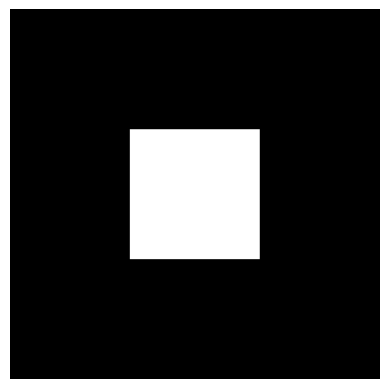

In [2]:
#I will be creating a 256x256 grid. For each pixel, I will always ask how far is the pixel it is from the center, if the distance is less than the radius, set that pixel to 1, otherwise 0.

#image is 256 pixels wide and 256 pixels tall
N = 256

target = np.zeros((N, N))
square_size = 90

start = N // 2 - square_size // 2
end = N // 2 + square_size // 2

target[start:end, start:end] = 1

#use matplotlib to show the square
plt.imshow(target, cmap="gray") #0 = gray and 1 = white
plt.axis("off")
plt.show()

In [3]:
#the phase mask is created by a random 256x256 grid of random numbers between 0 and 2pi

phase = np.random.rand(N, N) * 2 * np.pi #create a random 256x256 grid of random numbers between 0 and 2pi

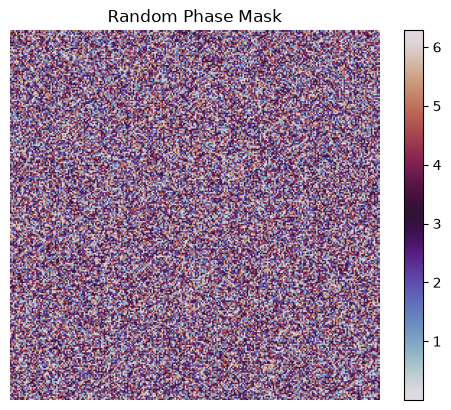

In [4]:
#plot the phase mask
plt.imshow(phase, cmap="twilight")
plt.title("Random Phase Mask")
plt.axis("off")
plt.colorbar()
plt.show()


In [5]:
#1j means the imaginary number i
#np.exp(1j * phase) = e^(i * phase)
#this will create a wave with amplitude = 1 and phase = phase value
#phase array -> complex phase array

field = np.exp(1j * phase) 

print(field.shape)
print(field[0, 0])


(256, 256)
(0.6486093190767369+0.7611215088320732j)


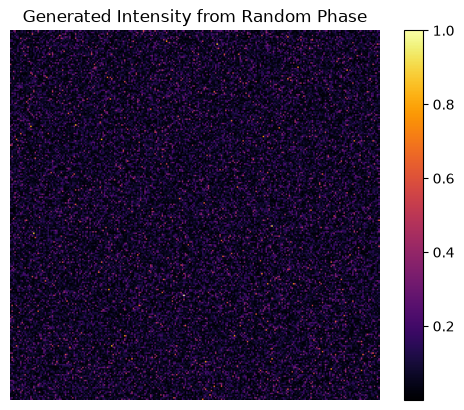

In [6]:
#apply Fourier transform

#in this part, I converted the phase mask into a complex wave field using the exp(i * phase). Then I used a 2D Fourier transform to simulate the 
#far-field pattern. Optical detectors measure intensity, I took the magnitude of complex wave then squares it to get intensity, then I scale 
#scale them down for plotting

far_field = np.fft.fft2(field) #take the 2D Fourier transform of the wave field\

#by default, the zero-frequency/center part is placed at the corner, fftshift will move it to the center
far_field = np.fft.fftshift(np.fft.fft2(field)) #this create another 2D complex array

intensity = np.abs(far_field) ** 2 #get the magnitude of the complex wave then squares it to get intensity
intensity = intensity/intensity.max() #scale it down to 0 = dark and 1 = brightest point

plt.imshow(intensity, cmap="inferno")
plt.title("Generated Intensity from Random Phase")
plt.axis("off")
plt.colorbar()
plt.show()

In [7]:
#Gerchberg-Saxton -> I start with a phase mask, I simulated its far-field wave, then I kept the far-field wave phase but
#replaced the amplitude with my target amplitude. Then I transformed back to the input plane and kept only the new phase
#that new phase becomes my updated phase mask

#intensity = amplitude^2

target_amplitude = np.sqrt(intensity)

#get the current far-field wave
field = np.exp(1j * phase)
far_field = np.fft.fftshift(np.fft.fft2(field))

#get the phase angle of a complex number
far_phase = np.angle(far_field)

#this will use the target amplitude that we want but will keep the phase from the current far-field wave
new_far_field = target_amplitude * np.exp(1j * far_phase)

#far-field -> input plane
back_field = np.fft.ifft2(np.fft.ifftshift(new_far_field))

#keep only the new phase
phase = np.angle(back_field)

In [8]:
target_amplitude = np.sqrt(target)
errors = []

for i in range(100):
    field = np.exp(1j * phase) #turn face mask into light wave
    far_field = np.fft.fftshift(np.fft.fft2(field)) #simulate the output light

    #convert wave into brightness
    intensity = np.abs(far_field) ** 2
    intensity = intensity/intensity.max()

    #error log
    error = np.mean((intensity - target) ** 2)
    errors.append(error)
    print("iteration:", i, "error:", error)

    #force the output brightness toward the target
    far_phase = np.angle(far_field)
    new_far_field = target_amplitude * np.exp(1j * far_phase)

    #go back and make a new phase mask
    back_field = np.fft.ifft2(np.fft.ifftshift(new_far_field))
    phase = np.angle(back_field)
    

iteration: 0 error: 0.11733759654568998
iteration: 1 error: 0.05553136195818771
iteration: 2 error: 0.04291644529948585
iteration: 3 error: 0.044062729533954244
iteration: 4 error: 0.042709203816428454
iteration: 5 error: 0.03813317543948712
iteration: 6 error: 0.03580101844282928
iteration: 7 error: 0.03421046300865272
iteration: 8 error: 0.032751716300256126
iteration: 9 error: 0.03185225966199611
iteration: 10 error: 0.03026489565765189
iteration: 11 error: 0.029110838907179547
iteration: 12 error: 0.028281636384093478
iteration: 13 error: 0.027631559688975557
iteration: 14 error: 0.02672826923945229
iteration: 15 error: 0.02645929867166892
iteration: 16 error: 0.0262561636276872
iteration: 17 error: 0.026619221784941298
iteration: 18 error: 0.026720577612413858
iteration: 19 error: 0.026879464888977897
iteration: 20 error: 0.026890506228973862
iteration: 21 error: 0.026764764739701484
iteration: 22 error: 0.026634047151402267
iteration: 23 error: 0.026589853853923484
iteration: 24 

In [12]:
starting_error = errors[0]
final_error = errors[-1]
improvement = starting_error - final_error

print(f"Starting error: {starting_error:.6f}")
print(f"Final error: {final_error:.6f}")
print(f"Improvement: {improvement:.6f}")

Starting error: 0.117338
Final error: 0.028171
Improvement: 0.089166


In [13]:
#generate final result from the updated phase
#this is phase -> wave field -> Fourier transform -> intensity result

field = np.exp(1j * phase)

far_field = np.fft.fftshift(np.fft.fft2(field))

result = np.abs(far_field) ** 2
result = result / result.max()

target_mask = target > 0.5

# Efficiency: how much light lands inside the target region
efficiency = result[target_mask].sum() / result.sum()

# Uniformity: how even the brightness is inside the target region
inside_values = result[target_mask]
mean_inside = inside_values.mean()
std_inside = inside_values.std()

non_uniformity = std_inside / mean_inside
uniformity_score = 1 / (1 + non_uniformity)

print(f"Efficiency: {efficiency:.6f}")
print(f"Non-uniformity: {non_uniformity:.6f}")
print(f"Uniformity score: {uniformity_score:.6f}")

Efficiency: 0.948197
Non-uniformity: 0.163569
Uniformity score: 0.859425


In [ ]:
#The square target achieved high efficiency, with about 94.8% of the generated intensity landing inside the target region. 

#Its non-uniformity value of 0.164 is slightly higher than the circle case, 
#which may be due to the sharper edges and corners of the square target. 

#Even so, the uniformity score of 0.859 suggests that the generated square pattern is still 
#reasonably uniform for this simplified phase-only model.

In [14]:
## Phase Quantization Experiment

#This experiment tests what happens when the optimized phase mask is limited to a fixed number of phase levels. 
#This is useful because real fabricated optical devices may not support perfectly continuous phase values.

def quantize_phase(phase, levels):
    phase_wrapped = np.mod(phase, 2 * np.pi)
    step = 2 * np.pi / levels
    return np.round(phase_wrapped / step) * step


In [15]:
phase_levels = [16, 8, 4, 2]

for levels in phase_levels:
    q_phase = quantize_phase(phase, levels)
    
    field = np.exp(1j * q_phase)
    fft_field = np.fft.fftshift(np.fft.fft2(field))
    
    q_intensity = np.abs(fft_field) ** 2
    q_intensity = q_intensity / q_intensity.max()
    
    q_error = np.mean((q_intensity - target) ** 2)
    
    print(f"{levels} phase levels error: {q_error:.6f}")

16 phase levels error: 0.029153
8 phase levels error: 0.027927
4 phase levels error: 0.046587
2 phase levels error: 0.067030


In [ ]:
#More phase levels = more precise phase mask = better result
#Fewer phase levels = rougher phase mask = worse result

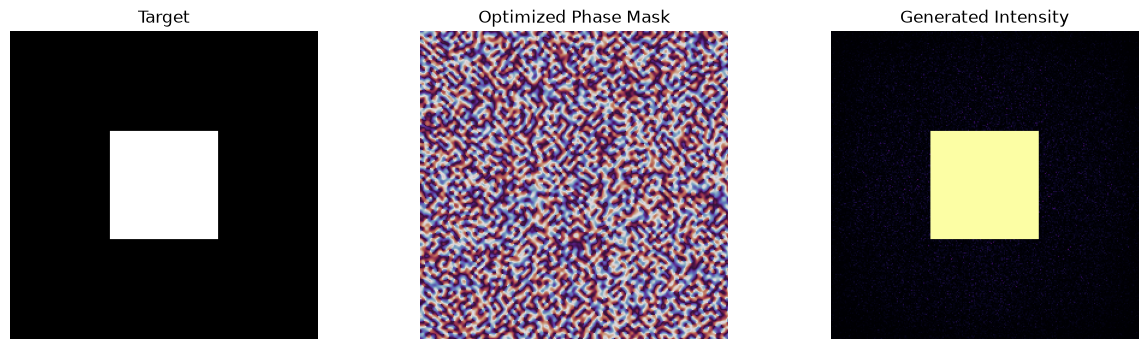

In [10]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(target, cmap="gray")
plt.title("Target")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(phase, cmap="twilight")
plt.title("Optimized Phase Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result, cmap="inferno", vmax= 0.2)
plt.title("Generated Intensity")
plt.axis("off")

plt.show()


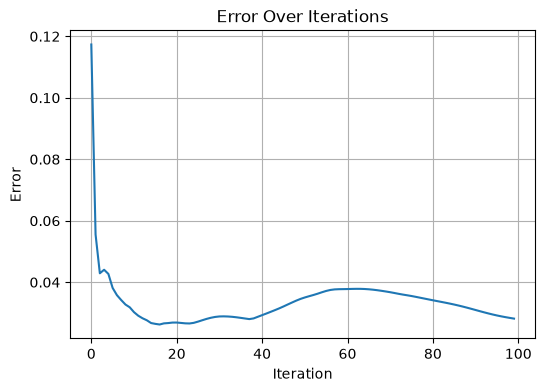

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(errors)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error Over Iterations")
plt.grid(True)
plt.show()

In [ ]:
#The square demo has sharper edges and corners compared to the circle.
#The generated result preserves the general square shape, although some non-uniformity remains near the edges.